In [1]:
%env HF_TRANSFER=1

env: HF_TRANSFER=1


In [2]:
!nvidia-smi

Mon Dec  1 14:42:00 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-16GB           On  |   00000000:85:00.0 Off |                    0 |
| N/A   35C    P0             43W /  300W |       0MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os

import torch
import logging
logger = logging.getLogger("ignite.handlers.early_stopping.EarlyStopping")
logger.setLevel(logging.WARNING)


import torch

import numpy as np

import torch
import itertools
from tqdm import tqdm
import os
import pandas as pd
import pyarrow as pa
import pyarrow.parquet as pq
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor, as_completed


import itertools


import torch
import os


import pandas as pd
from concurrent.futures import as_completed

from explanations import KRandom, Self
    
import logging
logging.getLogger().setLevel(logging.WARNING)



import logging
from concurrent.futures import ProcessPoolExecutor, as_completed
import torch
import multiprocessing
from tqdm import tqdm
import itertools
import pandas as pd
import traceback



logging.basicConfig(level=logging.ERROR, format='%(asctime)s [%(levelname)s] %(message)s')






multiprocessing.set_start_method('spawn', force=True)   
torch.manual_seed(42)
from load_experiment_data import (
train_dataset_name,
test_dataset_name,
train_dataset_split,
test_dataset_split,
load_data_and_estimators,
explanation_types,
linear_coders,
explanation_k,
explanation_seed
)
train_dataset, test_dataset, estimators = load_data_and_estimators()


/root/.local/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/root/.local/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `ty

influence_estimate_path: ./results/influence/DataInfEstimator/8192-True/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test/estimate.parquet
dirname: ./results/influence/DataInfEstimator/8192-True/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test
exists: True
influence_estimate_path: ./results/influence/BM25Estimator/1.5-0.75/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test/estimate.parquet
dirname: ./results/influence/BM25Estimator/1.5-0.75/OLMo-2-0425-1B_tulu-3-sft-olmo-2-mixture-0225_lr0.0001_seed42/tulu-3-sft-olmo-2-mixture-0225-sample_train/tulu-3-sft-olmo-2-mixture-0225-sample_test
exists: True
influence_estimate_path: ./results/influence/LESSEstimator/8192-True/OLMo-2-0425-1B_tulu-3-sft-o

In [ ]:
from explanations import TopKMostHelpful, Explanation,TopKMostHarmful, TopKMostInfluential,TopKLeastInfluential,DIVINEMostHelpful, DIVINEMostHarmful,FacilityLocationMostHarmful,FacilityLocationMostInfluential,FacilityLocationLeastInfluential,DIVINEMostInfluential,DIVINELeastInfluential,FacilityLocationMostHelpful#,AIDE
from fl_optimizers import LazyWeightedGreedy
from sklearn.preprocessing import RobustScaler, MinMaxScaler
from explanations import ImportanceLookupSelector
from apricot import FacilityLocationSelection, MixtureSelection, SumRedundancySelection, FeatureBasedSelection
from apricot.optimizers import LazyGreedy
from sklearn.metrics import pairwise_distances


In [5]:
from explanations import AIDE


In [ ]:
from abc import ABC, abstractmethod
import numpy
from numba import njit



In [7]:
from sklearn.preprocessing import RobustScaler, MinMaxScaler


In [ ]:
# def plot(base_explanation_class, divine_explanation_class, fl_explanation_class, estimator = estimators[2]):
#     def get_gradients_selection(explanation):
#         return torch.stack(estimator.get_gradient(train_dataset_name, train_dataset_split, explanation.documents)).to(torch.float32).numpy()

#     for test_idx in [0,999,100]:
        
#         for k in [5,10,25]:
#             print(f"################{k}##########")
#             base_explanation = fl_explanation_class(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, keep_gradients=True)
#             gradients_groundset = torch.stack(estimator.get_gradient(train_dataset_name, train_dataset_split, base_explanation.groundset_explanation.documents)).to(torch.float32).numpy()
#             gradient_test_instance = estimator.get_gradient(train_dataset_name, train_dataset_split, base_explanation.document_idx).to(torch.float32).numpy()
#             costs_groundset = base_explanation.costs[base_explanation.groundset_explanation.documents]
#             costs_groundset = MinMaxScaler((1, 2)).fit_transform(((costs_groundset.values.reshape(-1, 1)))).flatten()

#             plot_tsne(gradients_groundset, gradient_test_instance, costs=costs_groundset, methods=[
#                 (f"naive Top-{k}", get_gradients_selection(base_explanation_class(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k ))), 
#                 ]+[("DIVINE", get_gradients_selection(divine_explanation_class(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, keep_gradients=True))),
#                    ("AIDE", get_gradients_selection(AIDE(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, keep_gradients=True)))]                  
#                 +[(f"λ={lambda_}", get_gradients_selection(fl_explanation_class(test_idx, estimator, train_dataset_name, train_dataset_split, test_dataset_name, test_dataset_split, k=k, m=100, lambda_=lambda_ , keep_gradients=True))) for lambda_ in [0,0.25,0.5,0.75,1]],\
#                     vmax_percentile=100)

In [9]:
from influence_estimation.util import tokenize_dataset
from finetune import load_tokenizer

In [10]:
tokenizer = load_tokenizer("allenai/OLMo-2-0425-1B")

In [ ]:
import time


In [12]:
from sentence_transformers import SentenceTransformer
import torch

# embedding_model = SentenceTransformer("Qwen/Qwen3-Embedding-0.6B")
embedding_model = SentenceTransformer(
    "Qwen/Qwen3-Embedding-0.6B",
    # model_kwargs={ "device_map": "cuda", "dtype":torch.bfloat16},
    tokenizer_kwargs={"padding_side": "left"},

)
EMB_CACHE = {}



In [13]:
!nvidia-smi

Mon Dec  1 14:42:31 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla V100-SXM2-16GB           On  |   00000000:85:00.0 Off |                    0 |
| N/A   36C    P0             69W /  300W |    2586MiB /  16384MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [14]:
import matplotlib.colors as mcolors

base_colors = (
    (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
    (0.4, 0.7607843137254902, 0.6470588235294118),
    (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
    
    (0.9058823529411765, 0.5411764705882353, 0.7647058823529411),
    (0.6509803921568628, 0.8470588235294118, 0.32941176470588235),
    (1.0, 0.8509803921568627, 0.1843137254901961),
    (0.8980392156862745, 0.7686274509803922, 0.5803921568627451),
    (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)
)

def darken_color(rgb, factor=0.9):
    return tuple(factor * c for c in rgb)

# Example: make all colors 10% darker
base_colors = [darken_color(c, 0.9) for c in base_colors]

print(base_colors)

[(0.49764705882352944, 0.5647058823529412, 0.7164705882352941), (0.36000000000000004, 0.6847058823529412, 0.5823529411764706), (0.8894117647058825, 0.49764705882352944, 0.3458823529411765), (0.8152941176470588, 0.48705882352941177, 0.6882352941176471), (0.5858823529411765, 0.7623529411764706, 0.2964705882352941), (0.9, 0.7658823529411765, 0.16588235294117648), (0.808235294117647, 0.691764705882353, 0.5223529411764707), (0.6317647058823529, 0.6317647058823529, 0.6317647058823529)]


In [15]:

_tsne_cache = {}  # global cache for PCA+TSNE
cache = {}

In [16]:

import torch
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.spatial import ConvexHull
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics.pairwise import cosine_distances

import seaborn as sns
from matplotlib.patches import Polygon
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

from sklearn.manifold import locally_linear_embedding
from sklearn.manifold import MDS

def plot_single_grid(
    title,
    gradients_groundset,
    gradient_test_instance,
    embeddings_groundset,
    embedding_test_instance,
    methods=None,
    costs=None,
    vmax_percentile=95,
    n_rows=2,
    n_cols=8,
    figsize=(20, 8),
    k=None,
    test_idx=None,
    use_cosine=False,
    dim_reduction_method="tsne",
    
 
):
    # Convert torch tensors to numpy
    def to_numpy(x):
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
        return x

    gradients_groundset = to_numpy(gradients_groundset)
    gradient_test_instance = to_numpy(gradient_test_instance)
    embeddings_groundset = to_numpy(embeddings_groundset)
    embedding_test_instance = to_numpy(embedding_test_instance)
    if costs is not None:
        costs = to_numpy(costs)



    

    def compute_tsne(embedding_type, test_idx, data, test_instance, n_pca_components=50, perplexity=10):
        cache_key = ("tsne", embedding_type, test_idx, use_cosine)
        combined = np.vstack([data, test_instance.reshape(1, -1)])

        if cache_key in cache:
            xs, ys, pca, tsne, x_reduced = cache[cache_key]
            print("cache hit")
        else:
            print("cache miss")

            # Normalize vectors if using cosine similarity
            if use_cosine:
                norms = np.linalg.norm(combined, axis=1, keepdims=True)
                combined = combined / (norms + 1e-10)  
            # PCA preprocessing
            pca = PCA(n_components=min(n_pca_components, combined.shape[1]))
            x_reduced = pca.fit_transform(combined)

            # t-SNE embedding
            tsne = TSNE(
                n_components=2,
                perplexity=perplexity,
                random_state=42,
                metric="cosine" if use_cosine else "euclidean",
                init='pca'
            )
            x_tsne = tsne.fit_transform(x_reduced)
            xs, ys = x_tsne[:, 0], x_tsne[:, 1]

            # Cache results
            cache[cache_key] = (xs, ys, pca, tsne, x_reduced)

        return xs[:-1], ys[:-1], xs[-1], ys[-1], pca, x_reduced

    def compute_pca2d(embedding_type, test_idx, data, test_instance):
        cache_key = ("pca2d", embedding_type, test_idx)
        combined = np.vstack([data, test_instance.reshape(1, -1)])

        if cache_key in cache:
            xs, ys, pca, x_reduced = cache[cache_key]
            print("cache hit (PCA2D)")
        else:
            print("cache miss (PCA2D)")
            # Reduce directly to 2D
            pca = PCA(n_components=2)
            x_reduced = pca.fit_transform(combined)
            xs, ys = x_reduced[:, 0], x_reduced[:, 1]
            cache[cache_key] = (xs, ys, pca, x_reduced)

        return xs[:-1], ys[:-1], xs[-1], ys[-1], pca, x_reduced

    def compute_mlle(
        embedding_type,
        test_idx,
        data,
        test_instance,
        n_neighbors=12,
        lle_method="standard",
        n_pca_components=50,
    ):
        # Cache key based on embedding type (grad/emb) and the test index
        cache_key = ("lle", embedding_type, test_idx, use_cosine)

        combined = np.vstack([data, test_instance.reshape(1, -1)])

        if cache_key in cache:
            xs, ys, pca, lle_result, x_reduced = cache[cache_key]
            print("cache hit (LLE)")
        else:
            print("cache miss (LLE)")

            # PCA preprocessing (same as your TSNE pipeline)
            pca = PCA(n_components=min(n_pca_components, combined.shape[1]))
            x_reduced = pca.fit_transform(combined)

            # Run LLE (gives 2D embedding + reconstruction error)
            X_2d, err = locally_linear_embedding(
                x_reduced,
                n_neighbors=n_neighbors,
                n_components=2,
                method = 'modified'
            )

            xs, ys = X_2d[:, 0], X_2d[:, 1]
            lle_result = (X_2d, err)

            # Cache everything
            cache[cache_key] = (xs, ys, pca, lle_result, x_reduced)

        return xs[:-1], ys[:-1], xs[-1], ys[-1], pca, x_reduced
    
    def compute_mds(
        embedding_type,
        test_idx,
        data,
        test_instance,
        n_pca_components=50,
        n_mds_components=2,
        metric=True,               # metric MDS (default)
        max_iter=300,
        n_init=4,
    ):
        # Cache key per embedding type (grad/emb) and test index
        cache_key = ("mds", embedding_type, test_idx, use_cosine)

        combined = np.vstack([data, test_instance.reshape(1, -1)])

        if cache_key in cache:
            xs, ys, pca, mds_model, x_reduced = cache[cache_key]
            print("cache hit (MDS)")
        else:
            print("cache miss (MDS)")

            # --- PCA preprocessing ---
            pca = PCA(n_components=min(n_pca_components, combined.shape[1]))
            x_reduced = pca.fit_transform(combined)

            # --- Run MDS ---
            mds = MDS(
                n_components=n_mds_components,
                metric=metric,
                max_iter=max_iter,
                n_init=n_init,
                random_state=42,
                dissimilarity=("cosine" if use_cosine else "euclidean"),   # PCA space → Euclidean distances
                n_jobs=-1
            )

            X_2d = mds.fit_transform(x_reduced)
            xs, ys = X_2d[:, 0], X_2d[:, 1]

            # Store full MDS model for consistency (even though sklearn's MDS has no .transform)
            mds_model = mds

            # Cache result
            cache[cache_key] = (xs, ys, pca, mds_model, x_reduced)

        return xs[:-1], ys[:-1], xs[-1], ys[-1], pca, x_reduced
        
    
    dim_reduction_method_fn = None
    if dim_reduction_method == "tsne":
        dim_reduction_method_fn = compute_tsne
    if dim_reduction_method == "mlle":
            dim_reduction_method_fn = compute_mlle
    if dim_reduction_method == "mds":
            dim_reduction_method_fn = compute_mds
    if dim_reduction_method == "pca2d":
            dim_reduction_method_fn = compute_pca2d
    grad_x, grad_y, grad_test_x, grad_test_y, grad_pca, grad_reduced = dim_reduction_method_fn("grad", test_idx, gradients_groundset, gradient_test_instance)
    emb_x, emb_y, emb_test_x, emb_test_y, emb_pca, emb_reduced = dim_reduction_method_fn("emb", test_idx, embeddings_groundset, embedding_test_instance)

    # Colors & markers

    markers = ["o", "s", "^", "D", "P", "X", "v"]
    method_to_marker = {name: markers[i % len(markers)] for i, (name, *_) in enumerate(methods)}
    method_to_color = {name: base_colors[1:][i % len(base_colors[1:])] for i, (name, *_) in enumerate(methods)}


    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(n_rows, n_cols + 2, width_ratios=[0.15] + [1]*n_cols + [0.05], wspace=0, hspace=0)
    axes = []
    for r in range(n_rows):
        for c in range(n_cols):
            ax = fig.add_subplot(gs[r, c + 1]) 
            axes.append(ax)



    for i, (name, _,_,method_grad, method_emb) in enumerate(methods):
        method_grad = np.asarray(method_grad)
        method_emb = np.asarray(method_emb)

        # --- Gradients ---
        method_grad_pca = grad_pca.transform(np.vstack([gradients_groundset, method_grad]))[-len(method_grad):]
        if use_cosine:
            dists_grad = cosine_distances(grad_reduced[:-1], method_grad_pca)
        else:
            dists_grad = np.linalg.norm(grad_reduced[:-1, None, :] - method_grad_pca[None, :, :], axis=2)

        idx_grad = np.argmin(dists_grad, axis=0)
        ax_grad = axes[i]
        
        

        vmax = np.percentile(costs, vmax_percentile)
        norm = Normalize(vmin=np.min(costs), vmax=vmax)
        cmap = plt.get_cmap("berlin")
        ax_grad.scatter(grad_x, grad_y, c=costs, s=50, cmap=cmap, norm=norm, alpha=0.7, linewidths=0)
        
        
        ax_grad.scatter(grad_x[idx_grad], grad_y[idx_grad],
                        s=100, edgecolor=method_to_color[name], linewidth=2.5,
                        facecolor='none', marker=method_to_marker[name], color=method_to_color[name])
     #   ax_grad.scatter(grad_test_x, grad_test_y, s=60, color='black', marker='*', edgecolor='k', linewidth=1.5)
        ax_grad.set_title(f"{name}",fontsize=22)
        
        ax_grad.set_xticks([])
        ax_grad.set_yticks([])
        ax_grad.set_xlabel('')
        ax_grad.set_ylabel('')

        # --- Embeddings ---
        method_emb_pca = emb_pca.transform(np.vstack([embeddings_groundset, method_emb]))[-len(method_emb):]
        if use_cosine:
            dists_emb = cosine_distances(emb_reduced[:-1], method_emb_pca)
        else:
            dists_emb = np.linalg.norm(emb_reduced[:-1, None, :] - method_emb_pca[None, :, :], axis=2)
        idx_emb = np.argmin(dists_emb, axis=0)
        ax_emb = axes[i + n_cols]
        
        ax_emb.scatter(emb_x, emb_y, c=costs, s=50, cmap=cmap, norm=norm, alpha=0.7, linewidths=0)
        ax_emb.scatter(emb_x[idx_emb], emb_y[idx_emb],
                        s=100, edgecolor=method_to_color[name], linewidth=2.5,
                        facecolor='none', marker=method_to_marker[name], color=method_to_color[name])
        # ax_emb.scatter(emb_test_x, emb_test_y, s=60, color='red', marker='*', edgecolor='k', linewidth=1.5)

        ax_emb.set_xticks([])
        ax_emb.set_yticks([])
        ax_emb.set_xlabel('')
        ax_emb.set_ylabel('')
        ax_emb.set_facecolor("#e0e0e081")

        # Optionally draw convex hulls
        try:
            if len(idx_grad) > 2:
            
                hull = ConvexHull(np.column_stack([grad_x[idx_grad], grad_y[idx_grad]]))
                poly = Polygon(np.column_stack([grad_x[idx_grad], grad_y[idx_grad]])[hull.vertices],
                            closed=True, alpha=0.4, facecolor=method_to_color[name])
                ax_grad.add_patch(poly)

            if len(idx_emb) > 2:
                hull = ConvexHull(np.column_stack([emb_x[idx_emb], emb_y[idx_emb]]))
                poly = Polygon(np.column_stack([emb_x[idx_emb], emb_y[idx_emb]])[hull.vertices],
                            closed=True, alpha=0.4, facecolor=method_to_color[name])
                ax_emb.add_patch(poly)
        except:
            print("skipping")
        # Optionally color by cost
       
            
    row_titles = ['Loss-Gradients', 'Qwen3 Embeddings']
    for row_idx, row_title in enumerate(row_titles):
        ax_title = fig.add_subplot(gs[row_idx, 0])
        ax_title.text(0.2, 0.5, row_title, va='center', ha='left',  
                    rotation=90, fontsize=20, fontweight='bold', transform=ax_title.transAxes)
        ax_title.axis('off')

      
    if costs is not None:
        vmax = np.percentile(costs, vmax_percentile)
        norm = Normalize(vmin=np.min(costs), vmax=vmax)
        cmap = plt.get_cmap("berlin")
        sm = ScalarMappable(cmap=cmap, norm=norm)
        sm.set_array(costs)
        
        # Add colorbar to the last column (extra column in GridSpec)
        cbar_ax = fig.add_subplot(gs[:, -1])
        cbar = fig.colorbar(sm, cax=cbar_ax)
        cbar.ax.tick_params(labelsize=16)

    fig.tight_layout()
    
    os.makedirs("./figures/tsne_plots",exist_ok=True)
    filename = f"./figures/tsne_plots/k_{k}_idx_{test_idx}.pdf"
    fig.savefig(filename, format='pdf', bbox_inches='tight')
    plt.show()

In [17]:
target =[
  {
    "content": "Find the minimum value of the algebraic expression $|\\sin x+\\cos x+\\tan x+\\cot x+\\sec x+\\csc x|$ where $x$ is a real number.",
    "role": "user"
  },
  {
    "content": "To solve the problem of finding the minimum value of the expression \\( |\\sin x + \\cos x + \\tan x + \\cot x + \\sec x + \\csc x| \\), we can follow these steps:\n\n1. **Define the Variables and the Expression:**\n    Use SymPy to define the trigonometric variables and the expression.\n\n2. **Analyze the Domain:**\n    Determine the domain of the expression. The trigonometric functions \\(\\tan x\\), \\(\\cot x\\), \\(\\sec x\\), and \\(\\csc x\\) are undefined at certain points (where their respective denominators are zero).\n\n3. **Find Critical Points:**\n    Use differentiation to find the critical points of the expression within its domain.\n\n4. **Evaluate the Expression:**\n    Evaluate the expression at the critical points and at the endpoints of the domain, if necessary, to find the minimum value.\n\nLet's implement this in Python using SymPy:\n```python\nimport sympy as sp\n\n# Define the variable\nx = sp.symbols('x')\n\n# Define the expression\nexpr = sp.sin(x) + sp.cos(x) + sp.tan(x) + sp.cot(x) + sp.sec(x) + sp.csc(x)\n\n# Find the derivative of the expression\nexpr_diff = sp.diff(expr, x)\n\n# Find the critical points by solving the derivative equal to zero\ncritical_points = sp.solve(expr_diff, x, domain=sp.Reals)\n\n# We need to filter out the points where the expression is undefined\n# The expression is undefined where tan(x), cot(x), sec(x), or csc(x) are undefined\nundefined_points = set()\nfor n in range(-10, 10):  # Considering a small range for practical purposes\n    undefined_points.add(sp.S.Pi/2 + n * sp.Pi)  # points where tan(x), sec(x), csc(x) are undefined\n    undefined_points.add(n * sp.Pi)  # points where cot(x), csc(x) are undefined\n\n# Evaluate the expression at valid critical points\nvalid_critical_points = [p for p in critical_points if p not in undefined_points]\n\n# Evaluate the expression for each valid critical point\nmin_value = float('inf')\nfor point in valid_critical_points:\n    value = abs(expr.subs(x, point))\n    if value < min_value:\n        min_value = value\n\nprint(min_value)\n```\n```output\nTimed out after 5 seconds.\n```\nThe expression \\( |\\sin x + \\cos x + \\tan x + \\cot x + \\sec x + \\csc x| \\) is quite complex and involves trigonometric functions that can be undefined at many points. Instead of attempting to find an exact symbolic solution, which might be computationally expensive, we can take a numerical approach to approximate the minimum value.\n\nHere’s how we can approach this:\n\n1. **Define the Expression:**\n    Use SymPy to define the trigonometric variables and the expression.\n\n2. **Evaluate Numerically:**\n    Evaluate the expression at a large number of points within one period of the trigonometric functions (e.g., from \\(0\\) to \\(2\\pi\\)) to approximate the minimum value.\n\nLet's implement this approach in Python using SymPy and NumPy for numerical evaluation:\n```python\nimport sympy as sp\nimport numpy as np\n\n# Define the variable\nx = sp.symbols('x')\n\n# Define the expression\nexpr = sp.sin(x) + sp.cos(x) + sp.tan(x) + sp.cot(x) + sp.sec(x) + sp.csc(x)\n\n# Convert the sympy expression to a numerical function\nexpr_func = sp.lambdify(x, expr, 'numpy')\n\n# Define the domain for evaluation\ndomain = np.linspace(0, 2 * np.pi, 10000)  # Evaluating over one period with many points\n\n# Evaluate the expression numerically\nvalues = expr_func(domain)\n\n# Filter out invalid (undefined) values\nvalues = values[np.isfinite(values)]\n\n# Find the minimum absolute value\nmin_value = np.min(np.abs(values))\n\nprint(min_value)\n```\n```output\n1.82842712818488\n```\nThe numerical approach has given us an approximate minimum value of the expression \\( |\\sin x + \\cos x + \\tan x + \\cot x + \\sec x + \\csc x| \\approx 1.82842712818488 \\).\n\nTo summarize, the minimum value of the given expression, based on our numerical method, is:\n\\[\n\\boxed{1.82842712818488}\n\\]\n\nThis result should be a good approximation due to the high resolution of numerical points used over the interval \\([0, 2\\pi]\\).",
    "role": "assistant"
  }
]
matches = test_dataset.filter(
    lambda x, idx: x["messages"] == target,
    with_indices=True
)
matches["indices"]

Column([39])

In [18]:
matches

Dataset({
    features: ['id', 'messages', 'source', 'indices'],
    num_rows: 1
})

################ Top-5 for 171##########
first not most similar by cos sim
cache miss
cache miss


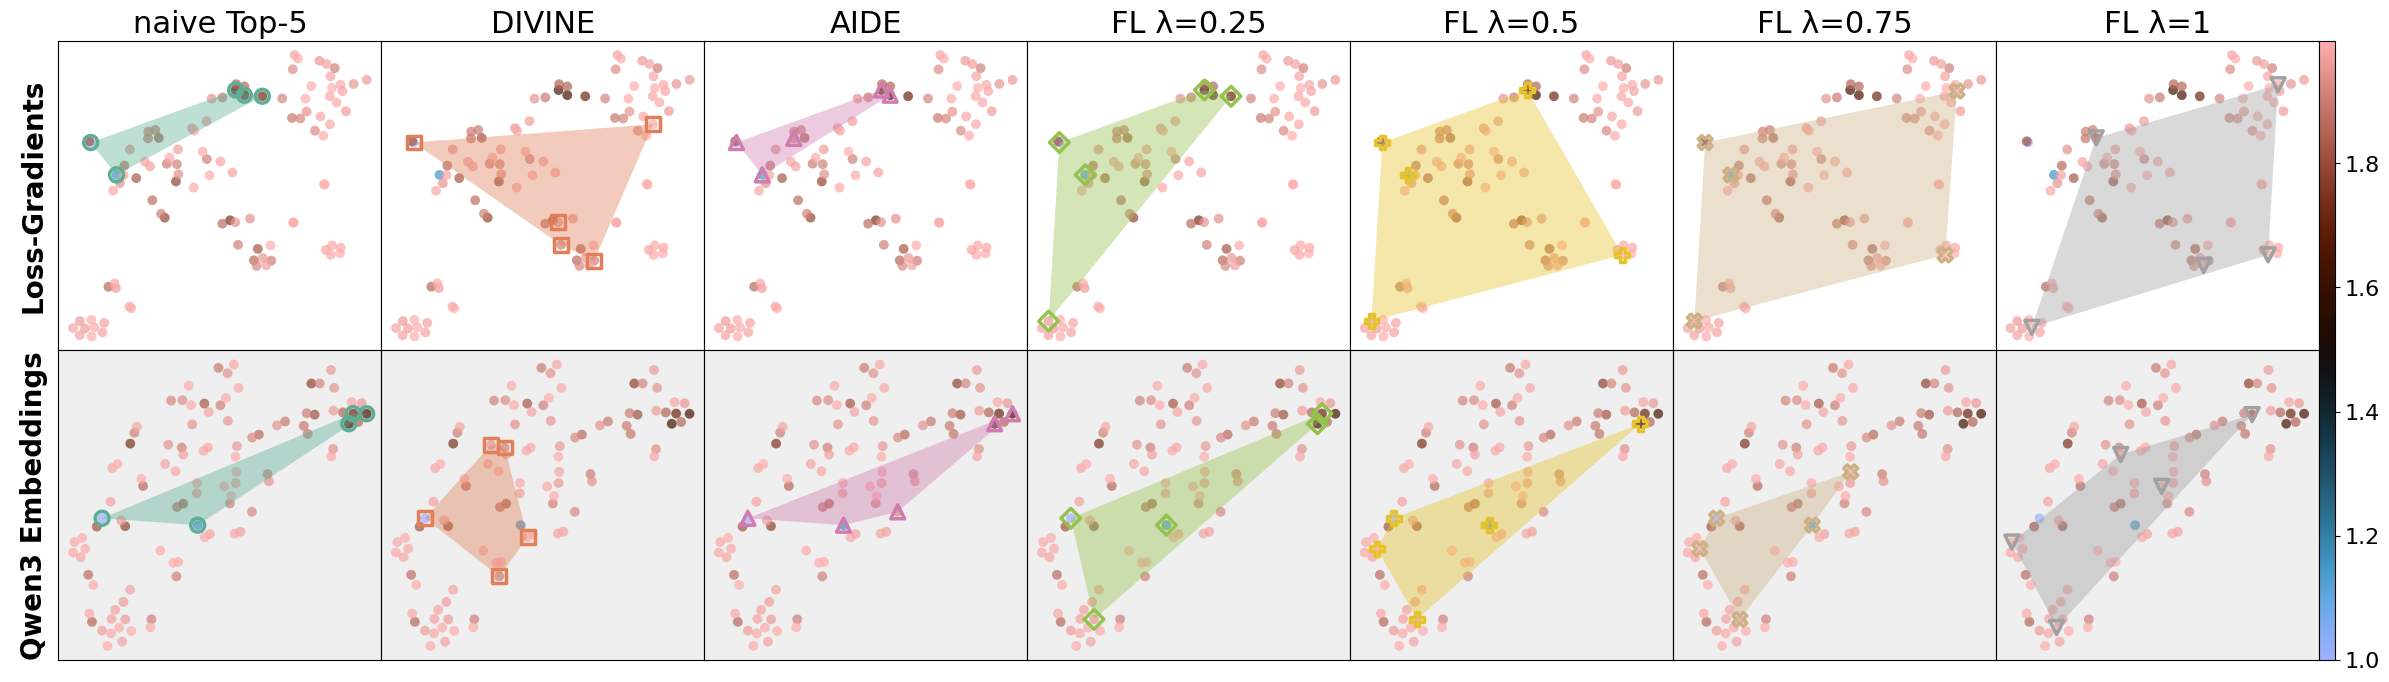

------------------------------------------------


In [19]:
def cached_encode(text,i):  
     
    if text in EMB_CACHE:
        return EMB_CACHE[text]
    # print("len", i, len(text),text)
    emb = embedding_model.encode(
        text, convert_to_numpy=True, normalize_embeddings=True,batch_size=1,#show_progress_bar=True
    )
    EMB_CACHE[text] = emb
    torch.cuda.empty_cache()
    return emb

mmethods = []
def plot(base_explanation_class, divine_explanation_class, fl_explanation_class, estimator=None,use_cosine=False,dim_reduction_method="tsne"):

    def get_gradients_selection(explanation):
        return torch.stack(estimator.get_gradient(train_dataset_name, train_dataset_split, explanation.documents)).to(torch.float32).numpy()

    def get_embeddings_selection(explanation):
        # lens = [
        #     len(tokenizer.apply_chat_template(messages, tokenize=True, truncate=True, max_lenght=1024))#, skip_special_tokens=True)
        #     for messages in train_dataset["messages"][explanation.documents]
        # ]
        # print(lens)
        texts = [
            tokenizer.decode(tokenizer.apply_chat_template(messages, tokenize=True)[0:4096], skip_special_tokens=True)
            for messages in train_dataset["messages"][explanation.documents]
        ]
        return np.stack([cached_encode(t,i) for i,t in enumerate(texts)])

    for test_idx in [171,
        428,
        416, # bad examples
        97, 348, # comply not alignment
        542, # unsupported modality
        39,1, # math
        950, # unique information 
        717, # non-english non-latin script
        997, # code        
        ]:
        for k in [5]:#,5,10,25]:
            print(f"################ Top-{k} for {test_idx}##########")
            
            base_explanation = fl_explanation_class(
                test_idx, estimator,
                train_dataset_name, train_dataset_split,
                test_dataset_name, test_dataset_split,
                k=k, m=100, keep_gradients=True
            )

            # Costs
            costs_groundset = base_explanation.costs[base_explanation.groundset_explanation.documents]
            costs_groundset = MinMaxScaler((1, 2)).fit_transform(costs_groundset.values.reshape(-1, 1)).flatten()

            # --- Gradients ---
            gradients_groundset = get_gradients_selection(base_explanation.groundset_explanation)
            gradient_test_instance = estimator.get_gradient(
                test_dataset_name, test_dataset_split, test_idx
            ).to(torch.float32).numpy()

            # --- Embeddings ---
            torch.cuda.empty_cache()
            embeddings_groundset = get_embeddings_selection(base_explanation.groundset_explanation)
            embedding_test_instance = embedding_model.encode(
                tokenizer.decode(tokenizer.apply_chat_template(test_dataset["messages"][test_idx], tokenize=True)[0:4096], skip_special_tokens=True),
                convert_to_numpy=True, normalize_embeddings=True, batch_size=1
            )

            # --- BUILD METHODS ---
            methods = []
            # naive
            naive_top_k_explanation = base_explanation_class(test_idx, estimator,
                                                                train_dataset_name, train_dataset_split,
                                                                test_dataset_name, test_dataset_split, k=k)
            grads_naive = get_gradients_selection(naive_top_k_explanation)
            methods.append((
                f"naive Top-{k}",
                naive_top_k_explanation.document_idx,
                naive_top_k_explanation.documents,
                grads_naive,
                get_embeddings_selection(naive_top_k_explanation)
            ))
           
            gradients_groundset_norm = gradients_groundset / (np.linalg.norm(
                gradients_groundset, axis=1, keepdims=True
            )+1e-10)

            # Normalize the test gradient
            gradient_test_instance_norm = gradient_test_instance / (np.linalg.norm(
                gradient_test_instance
            )+1e-10)

            # Cosine similarity for all 100 rows
            cos_sims = gradients_groundset_norm @ gradient_test_instance_norm
            print("first most similar by cosine sim" if base_explanation.groundset_explanation.documents[np.argmax(cos_sims)] == base_explanation.groundset_explanation.documents[0] else "first not most similar by cos sim")
                        
            # DIVINE
            divine_explanation = divine_explanation_class(test_idx, estimator,
                                                                 train_dataset_name, train_dataset_split,
                                                                 test_dataset_name, test_dataset_split,
                                                                 k=k, m=100, keep_gradients=True)
            methods.append((
                "DIVINE",
                divine_explanation.document_idx,
                divine_explanation.documents,
                get_gradients_selection(divine_explanation),
                get_embeddings_selection(divine_explanation)
            ))
            # AIDE
            AIDE_explanation = AIDE(test_idx, estimator,
                                             train_dataset_name, train_dataset_split,
                                             test_dataset_name, test_dataset_split,
                                             k=k, m=100, keep_gradients=True)
            methods.append((
                "AIDE",
                AIDE_explanation.document_idx,
                AIDE_explanation.documents,
                get_gradients_selection(AIDE_explanation),
                get_embeddings_selection(AIDE_explanation)
            ))
            # FL 
            for lambda_ in [0.25, 0.5, 0.75, 1]:
                fl_explanation = fl_explanation_class(test_idx, estimator,
                                                                 train_dataset_name, train_dataset_split,
                                                                 test_dataset_name, test_dataset_split,
                                                                 k=k, m=100, lambda_=lambda_, keep_gradients=True)
                methods.append((
                    f"FL λ={lambda_}",
                    fl_explanation.document_idx,
                    fl_explanation.documents,
                    get_gradients_selection(fl_explanation),
                    get_embeddings_selection(fl_explanation)
                ))

            plot_single_grid(
                title=f"Test idx {test_idx} - Top-{k}",
                gradients_groundset=gradients_groundset,
                gradient_test_instance=gradient_test_instance,
                embeddings_groundset=embeddings_groundset,
                embedding_test_instance=embedding_test_instance,
                methods=methods,
                costs=costs_groundset,
                n_rows=2,
                n_cols=7,
                figsize=(24, 7),
                test_idx=test_idx,
                k=k,
                use_cosine=use_cosine,
                dim_reduction_method=dim_reduction_method,
            )
           
              
    
            mmethods.append(methods)
            print("------------------------------------------------")
            
        break

            

# plot(TopKMostInfluential, DIVINEMostInfluential, FacilityLocationMostInfluential, use_cosine=False, estimator = estimators[0])
# plot(TopKLeastInfluential, DIVINELeastInfluential, FacilityLocationLeastInfluential, use_cosine=False)
plot(TopKMostHelpful, DIVINEMostHelpful, FacilityLocationMostHelpful, use_cosine=True, dim_reduction_method="tsne",estimator = estimators[0])
# plot(TopKMostHarmful, DIVINEMostHarmful, FacilityLocationMostHarmful,use_cosine=False)

In [20]:
# def format_chat(x):
#     return tokenizer.apply_chat_template(x, tokenize=False)

[{'content': 'Is the number \\(11 \\times 21 \\times 31 \\times 41 \\times 51 - 1\\) divisible by 10?', 'role': 'user'}, {'content': "To determine whether the number \\(11 \\times 21 \\times 31 \\times 41 \\times 51 - 1\\) is divisible by 10, we need to check if it is divisible by both 2 and 5.\n\n1. **Divisibility by 2**: A number is divisible by 2 if its last digit is even.\n2. **Divisibility by 5**: A number is divisible by 5 if its last digit is 0 or 5.\n\nLet's break down the problem:\n\n1. We will calculate \\(11 \\times 21 \\times 31 \\times 41 \\times 51\\) modulo 10.\n2. Then, we will subtract 1 from the result and check if the final result is divisible by 10.\n\nLet's use Python and sympy to help with these calculations.\n\n```python\nimport sympy as sp\n\n# Define the product of the numbers\nproduct = 11 * 21 * 31 * 41 * 51\n\n# Calculate the product modulo 10\nproduct_mod_10 = product % 10\n\n# Subtract 1 from the product and check if it's divisible by 10\nresult = (product

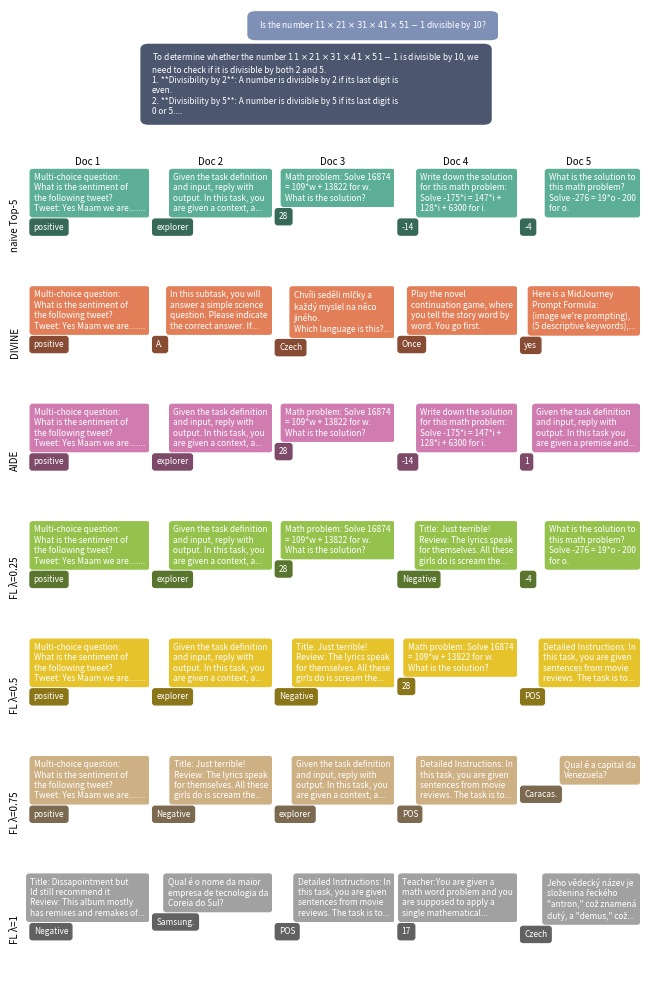

In [22]:


import matplotlib.font_manager as fm
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import textwrap
import matplotlib as mpl
import matplotlib.patches as patches
import re
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D

def darken_color(color, amount=0.6):
    """
    Darkens the given color by multiplying (1-luminosity) by amount.
    """
    c = mcolors.to_rgb(color)
    return tuple([amount * x for x in c])
# --- Register fonts ---
fm.fontManager.addfont("NotoSansCJKtc-Regular.otf")
fm.fontManager.addfont("NotoColorEmoji-Regular.ttf")
fm.fontManager.addfont("NotoSansEthiopic-VariableFont_wdth,wght.ttf")
fm.fontManager.addfont("NotoSansTelugu-VariableFont_wdth,wght.ttf")
mpl.rcParams['font.family'] = ['Noto Sans CJK TC', 'Noto Color Emoji', 
                               'Noto Sans Ethiopic', 'Noto Sans Telugu', 'DejaVu Sans']
mpl.rcParams['mathtext.fontset'] = 'dejavusans' 
def draw_chat(ax, idx, messages, x0=0.02, y0=0.95, max_lines=10, line_chars=35, fontsize=5, line_chars_cjk=10):
    """
    Draw chat messages with rounded chat bubbles.
    Assistant messages: left, user messages: right.
    """
    chat_y = y0
  #  base_colors = cm.get_cmap("Set2").colors
    for i,msg in enumerate(messages):
        text = msg["content"]

        # --- Clean markdown / math ---
        text = re.sub(r'\\\((.*?)\\\)', r'$\1$', text, flags=re.DOTALL)
        text = re.sub(r'\\\[\s*(.*?)\s*\\\]', r'$\1$', text, flags=re.DOTALL)
        text = re.sub(r'^(#{1,3})\s*(.*)$', r'\2', text, flags=re.MULTILINE)
        text = text.replace(r"```python","")

                # --- Wrap lines ---
        def split_lines(text, line_chars, line_chars_cjk=20):
            # --- 1. Extract $$...$$ blocks so they are never split ---
            formula_map = {}
            def repl_formula(match):
                key = f"__FORMULA_BLOCK_{len(formula_map)}__"
                formula_map[key] = match.group(0)  # full $$...$$
                return key

            # Match $$...$$ including multiline
            text = re.sub(r'\$(.*?)\$', repl_formula, text, flags=re.DOTALL)

            # --- 2. Wrap normally (no formulas inside now) ---
            new_lines = []

            for line in text.splitlines():
                has_cjk = bool(re.search(r"[\u4e00-\u9fff]", line))

                # choose limit based only on CJK since formulas removed
                limit = line_chars_cjk if has_cjk else line_chars

                while len(line) > limit:
                    if has_cjk:
                        new_lines.append(line[:limit])
                        line = line[limit:]
                    else:
                        split_pos = line.rfind(' ', 0, limit)
                        if split_pos == -1:
                            split_pos = limit
                        new_lines.append(line[:split_pos].rstrip())
                        line = line[split_pos:].lstrip()
                if line:
                    new_lines.append(line)

            # --- 3. Reinsert formulas atomically, never split ---
            restored = []
            for line in new_lines:
                for key, formula in formula_map.items():
                    if key in line:
                        line = line.replace(key, formula)
                restored.append(line)
            return restored

        lines = split_lines(text, line_chars,line_chars_cjk=line_chars_cjk)

        # Apply max_lines truncation
        if max_lines is not None and len(lines) > max_lines:
            lines = lines[:max_lines]
            lines[-1] += "..."  # indicate truncation

        wrapped_text = "\n".join(lines)

        # Draw text temporarily to measure size
        txt = ax.text(0, chat_y, wrapped_text, va='top', ha='left', fontsize=fontsize,color="white")
        renderer = ax.figure.canvas.get_renderer()
        bbox = txt.get_window_extent(renderer=renderer)

        # Bubble dimensions
        bubble_height_axes = bbox.height / ax.bbox.height + 0.02
        bubble_width_axes = bbox.width / ax.bbox.width + 0.02
        
        if i % 2 == 0:
            color = base_colors[idx]   # first message: base Set2 color
        else:
            color = darken_color(base_colors[idx], amount=0.6)  # second message: darker

        # Bubble color & alignment
        if msg["role"] == "assistant":
            bubble_x = x0
            # color = "#D0F0C0"
        else:
            bubble_x = 1.0 - bubble_width_axes - 0.02
            # color = "#F0D0D0"

        # Draw rounded bubble
        rect = patches.FancyBboxPatch(
            (bubble_x, chat_y - bubble_height_axes),
            bubble_width_axes,
            bubble_height_axes,
            boxstyle="round,pad=0.02,rounding_size=0.02",
            fc=color,
            ec=color
        )
        ax.add_patch(rect)

        # Draw the text inside the bubble
        text_x = bubble_x + 0.01
        text_y = chat_y - 0.005
        txt.set_position((text_x, text_y))
        txt.set_ha('left')

        # Move to next message
        chat_y -= bubble_height_axes + 0.06

    return chat_y
def plot_chat_case_study(example_to_explain, docs, pdf_path="figures/chat_case_study_fixed.pdf"):
    page_width_pt = 455.24411
    page_height_pt = 704.60031
    page_width_in = page_width_pt / 72
    page_height_in = page_height_pt / 72

    fig = plt.figure(figsize=(page_width_in, page_height_in))
    fig.subplots_adjust(left=0.1, right=1, top=1, bottom=0)

    # Draw first "example to explain" box
    ax1 = fig.add_axes([0.194, 0.75, 0.582, 0.25])
    chat_end =draw_chat(ax1, 0, example_to_explain, x0=0.05, y0=0.97,  max_lines=6, line_chars=75,fontsize=6)
    # ax1.set_title("Example to Explain", fontsize=7, pad=5)

    ax1.set_xticks([])
    ax1.set_yticks([]) 
    ax1.set_frame_on(False)
    ax1_bottom_fig = ax1.get_position().y0  # bottom of ax1 in figure coords

    # Positions of document boxes
    margin_left = 0.03
    row_height = 0.12
    col_width = (1/5)*(1-margin_left)
    col_spacing = 0.00
    row_spacing = 0.00
    start_x = margin_left
    start_y = ax1_bottom_fig - 0.03  # small gap


    docs = [(method_name, docs_col) for method_name, docs_col in docs if "FL λ=0" != method_name]

    for r, (method_name, docs_col) in enumerate(docs): 
        y = start_y - r * (row_height + row_spacing)
        for c, doc in enumerate(docs_col): 
            x = start_x + c * (col_width + col_spacing)
            ax = fig.add_axes([x, y, col_width, row_height])
            method_name_display = method_name#.replace("naive Top-5",)# "naive Top-5 (FL λ=0)")
            chat_end = draw_chat(ax, r+1,doc, x0=0.05, y0=0.95,max_lines=4, line_chars=27, line_chars_cjk=10, fontsize=6)
            ax.set_xticks([]); ax.set_yticks([])
            ax.set_frame_on(False)
            # if r > 0:
            #     line = Line2D([start_x, 1.0], [y + row_height, y + row_height], 
            #         transform=fig.transFigure, color='gray', linewidth=1)
            #     fig.add_artist(line)
            if c == 0:
                fig.text(
                    x - 0.01, 
                    y + row_height / 2,  
                    method_name_display,
                    fontsize=7,
                    rotation=90,
                    va='center',
                    ha='right'
                )
            if r == 0:
                col_title = f"Doc {c+1}"  
                fig.text(
                    x + col_width/2,       
                    y + row_height , 
                    col_title,
                    fontsize=7,
                    ha='center',
                    va='bottom',
                    fontweight='bold' 
                )

    # border = patches.Rectangle(
    #     (0, 0), 1, 1, fill=False, edgecolor="red", linewidth=1, transform=fig.transFigure
    # )
    # fig.patches.append(border)
    plt.show()
    with PdfPages(pdf_path) as pdf:
        pdf.savefig(fig)

    plt.close(fig)
for methods in mmethods:
    docs = []
    for name, document_idx, explanation, _, _ in methods:
        docs.append((name,[(train_dataset[int(e)]["messages"]) for e in explanation]))
    print(test_dataset[document_idx]["messages"])
    print(docs)
    plot_chat_case_study(example_to_explain=test_dataset[document_idx]["messages"], docs=docs, 
                            pdf_path=f"figures/chat_case_study_{name.replace('λ','lambda')}_{document_idx}.pdf")
    

In [23]:
k = 10
base_explanation_class = TopKMostInfluential
divine_explanation_class = DIVINEMostInfluential
fl_explanation_class = FacilityLocationMostInfluential

test_indices = [100]  


# Store explanations for each method
ex = []

# Base Top-k
base_docs_all = []
for test_idx in test_indices:
    base_docs_all.extend(
        base_explanation_class(
            test_idx, estimator,
            train_dataset_name, train_dataset_split,
            test_dataset_name, test_dataset_split,
            k=k
        ).documents
    )
ex.append(("naive Top-{k}", list(set(base_docs_all))))

# DIVINE
divine_docs_all = []
for test_idx in test_indices:
    ee = divine_explanation_class(
            test_idx, estimator,
            train_dataset_name, train_dataset_split,
            test_dataset_name, test_dataset_split,
            k=k, m=100, keep_gradients=True
        )
    ee.documents
    print(ee.gamma)
    divine_docs_all.extend(
        ee.documents
    )
ex.append(("DIVINE", list(set(divine_docs_all))))

# Facility Location for different lambda
for lambda_ in [0, 0.25, 0.5, 0.75, 1]:
    fl_docs_all = []
    for test_idx in test_indices:
        fl_docs_all.extend(
            fl_explanation_class(
                test_idx, estimator,
                train_dataset_name, train_dataset_split,
                test_dataset_name, test_dataset_split,
                k=k, m=100, lambda_=lambda_, keep_gradients=True
            ).documents
        )
    ex.append((f"λ={lambda_}", list(set(fl_docs_all))))

# Create selection matrix and similarity
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

all_docs = set()
for _, docs in ex:
    all_docs.update(docs)
all_docs = sorted(all_docs)
doc_to_idx = {doc: i for i, doc in enumerate(all_docs)}

n = len(ex)
m = len(all_docs)
selection_matrix = np.zeros((n, m), dtype=int)
for i, (_, docs) in enumerate(ex):
    for doc in docs:
        selection_matrix[i, doc_to_idx[doc]] = 1

sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        intersection = np.sum(selection_matrix[i] & selection_matrix[j])
        union = np.sum(selection_matrix[i] | selection_matrix[j])
        sim_matrix[i, j] = intersection / union if union != 0 else 0

# Plot heatmap
labels = [label for label, _ in ex]
plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, xticklabels=labels, yticklabels=labels, annot=True, cmap="YlGnBu", vmin=0, vmax=1)
plt.title("Jaccard Similarity Between Explanations (Indices 0-100)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


NameError: name 'estimator' is not defined